# Phase 3 (part 12): the identifiability sweep for a neural model (MLP), and across model families

**What this is.** The high-value neural experiment. It extends the synthetic
identifiability sweep behind contribution **C3 / Fig. 5** from the tree models
(RF, XGBoost) to an **MLP**, answering the reviewer's key open question:

> *Does the redundancy / identifiability failure persist in neural models, or is
> it tree-specific?*

**Design.** A fully controlled, known-ground-truth construction (the 07g logic):
decorrelated Gaussian features with a planted relevant set $S$; the label is a
median split of $X_S w$, so the concept is defined by $S$ while $P(X)$ is held
fixed across the pre/post windows. We sweep the correlation $\rho$ between each
relevant feature and a redundant partner placed **outside** $S$, which raises the
target's external leakage toward $1$. We then measure how well each method
recovers $S$ (precision@K) as $\rho$ rises.

**Why all three model families on one construction.** Rather than cite the old
tree run, we re-run RF, XGBoost, **and** the MLP on the *same* arms and seeds, so
the three degradation curves are directly comparable in a single figure. KS is
carried as the concept-blind baseline: because $P(X)$ is identical pre/post, KS
has nothing to localise and should sit at chance at every $\rho$.

- Tree models use the validated TreeSHAP path (`shap_importance`).
- The MLP uses the validated model-agnostic path
  (`agnostic_shap_importance`), established and gated in notebook 11 (F016).
- Both are reached through `shap_importance_any`, now in
  `src/divergence/localization.py`.

**Pre-registered gate (D029), committed before execution.**
- *NEURAL-IDENTIFIABILITY-CONFIRMED* iff the MLP behaves like the trees:
  MLP-SHAP precision@K $\ge 0.80$ at $\rho{=}0$, **and** it drops by $\ge 0.20$
  from $\rho{=}0$ to $\rho{=}0.99$, **with** valid recall ($\ge 0.70$) at every
  $\rho$ (so a failure to recover is identifiability, not an unlearned model).
- Otherwise *NEURAL-IDENTIFIABILITY-NOT-CONFIRMED* — the failure would be
  (partly) tree-specific, which would itself be reportable.

If confirmed, the structural limit (C3) is **model-class-independent**, and the
paper can state the identifiability mechanism holds for neural IDS models too.

**Runtime.** ~15--25 min on a Colab hi-RAM instance; MLP-SHAP (permutation
explainer) over the $\rho$ grid dominates the cost. Trees are fast.

Numbering: 12, a Phase-3 generalization notebook (`05_phase3_generalization/`).
Requires the F016 functions in `src/divergence/localization.py` (notebook 11, step 1).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, precision_at_k, random_precision_expectation,
)
# the model-agnostic path validated in notebook 11 (step 1: now in src)
try:
    from src.divergence.localization import shap_importance_any, agnostic_shap_importance
except ImportError as e:
    raise ImportError(
        'Add agnostic_shap_importance and shap_importance_any to '
        'src/divergence/localization.py first (notebook 11, step 1).'
    ) from e

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase3_12_mlp_identifiability.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
COLOR = {'mlp': '#56B4E9', 'rf': '#E69F00', 'xgb': '#009E73', 'ks': '#0072B2'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='12_mlp_identifiability_sweep'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

Setup complete.


## 2. D029 — the cross-model identifiability sweep and the pre-registered gate

In [3]:
log_decision(
    decision_id='D029',
    decision=(
        'Extend the synthetic identifiability sweep (C3 / Fig. 5) from RF + '
        'XGBoost to an MLP, on a single shared construction so the curves are '
        'directly comparable. Known-GT concept arm (07g logic): decorrelated '
        'Gaussian features, planted relevant set S, label = median split of '
        'X_S w, P(X) held fixed across pre/post. Sweep partner-correlation rho '
        'in {0,0.2,0.4,0.6,0.8,0.9,0.99} (raises external leakage of the target). '
        'For each (rho, model, seed): train the model on the post arm, recover S '
        'by precision@K from SHAP (TreeSHAP for RF/XGB, the validated agnostic '
        'path for the MLP, dispatched by shap_importance_any), gate on recall. '
        'KS(pre,post) carried as the concept-blind baseline (chance, since P(X) '
        'is fixed). Pre-registered gate (committed before execution): '
        'NEURAL-IDENTIFIABILITY-CONFIRMED iff MLP precision@K >= 0.80 at rho=0 '
        'AND MLP drop (rho=0 minus rho=0.99) >= 0.20 AND MLP recall >= 0.70 at '
        'every rho; else NOT-CONFIRMED.'
    ),
    rationale=(
        'The reviewer asks whether the SHAP localization failure is tree-specific. '
        'A controlled rho sweep on the MLP, on the same arms as the trees, answers '
        'it directly: if the MLP degrades with redundancy like the trees, the C3 '
        'structural limit is model-class-independent. The MLP-SHAP path used here '
        'was pre-validated in notebook 11 (F016), so a neural negative is credible. '
        'P(X) is held fixed so KS sits at chance -- the failure is about '
        'identifiability of the target, not about input drift.'
    ),
    alternatives=(
        'Cite the old 07g tree numbers and add an MLP-only curve (rejected: not '
        'same-run comparable). Vary rho via a covariate shift (rejected: would let '
        'KS localise and confound the identifiability question). Add CNN/LSTM/TabNet '
        '(rejected: out of scope; one neural family answers the tree-specific '
        'question with the best effort-to-impact ratio).'
    ),
)

[DECISION LOGGED] D029


## 3. Configuration

Width matches UNSW (`N_FEATURES=42`). The MLP recipe is identical to the one
validated in notebook 11. Thresholds are committed here, before any model runs.

In [4]:
set_global_seed(42)

# --- models ---
MODELS = ['mlp', 'rf', 'xgb']             # SHAP curves
MLP_PARAMS = dict(hidden_layer_sizes=(256, 128, 64), activation='relu',
                  alpha=1e-4, max_iter=300, early_stopping=True,
                  n_iter_no_change=15, random_state=42)   # == notebook 11

def make_model(kind, seed):
    if kind == 'mlp':
        return MLPClassifier(**{**MLP_PARAMS, 'random_state': seed})
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

# --- construction + sweep ---
N_ROWS = 12000
N_FEATURES = 42
REL_SIZE = 5
K_PRIMARY = REL_SIZE
SEEDS = [42, 1, 7]
RHO_GRID = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99]
SHAP_EVAL_N = 400          # eval rows (matches the validated infra setting)

# --- pre-registered gate (D029) ---
RHO0_MIN = 0.80            # MLP must recover the decorrelated target at rho=0
DROP_MIN = 0.20            # MLP precision must fall by >= this from rho=0 to rho=0.99
RECALL_MIN = 0.70          # model must have learned the task at every rho

CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
print(f'features {N_FEATURES} | rel_size {REL_SIZE} | chance precision@{K_PRIMARY} = {CHANCE:.3f}')
print(f'models {MODELS} | rho grid {RHO_GRID}')
print(f'gate: rho0 >= {RHO0_MIN}, drop >= {DROP_MIN}, recall >= {RECALL_MIN}')

features 42 | rel_size 5 | chance precision@5 = 0.119
models ['mlp', 'rf', 'xgb'] | rho grid [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99]
gate: rho0 >= 0.8, drop >= 0.2, recall >= 0.7


## 4. The known-ground-truth arm (P(X) fixed; concept defined by $S$)

`make_arm` fixes the relevant set $S$, its outside-$S$ partners, and the weight
vector $w$ for the arm, then draws **pre** and **post** windows from the *same*
distribution (so KS sees no drift). Labels on the post window come from $X_S w$.
As `rho` rises, each $s\in S$ gains a correlated partner outside $S$, raising the
target's external leakage.

In [5]:
def make_arm(d, rel_size, seed, rho):
    rng = np.random.default_rng(seed)
    S = np.sort(rng.choice(d, size=rel_size, replace=False))
    others = np.array([j for j in range(d) if j not in set(int(i) for i in S)])
    partners = rng.choice(others, size=rel_size, replace=False) if rho > 0 else None
    w = rng.normal(size=rel_size)

    def draw(n, r):
        X = r.standard_normal((n, d))
        if rho > 0:
            for i, p in zip(S, partners):
                X[:, p] = rho * X[:, i] + np.sqrt(1 - rho ** 2) * r.standard_normal(n)
        mu, sd = X.mean(0), X.std(0); sd[sd == 0] = 1.0
        return (X - mu) / sd

    X_pre = draw(N_ROWS, np.random.default_rng(seed + 100))
    X_post = draw(N_ROWS, np.random.default_rng(seed + 200))
    score = X_post[:, S] @ w
    y_post = (score > np.median(score)).astype(int)
    return X_pre, X_post, y_post, set(int(i) for i in S)

# sanity: same distribution pre/post -> KS at chance; balanced labels
_pre, _post, _y, _gt = make_arm(N_FEATURES, REL_SIZE, 42, rho=0.6)
_ks = ks_drift_scores(_pre, _post)
print('label balance', round(float(_y.mean()), 3),
      '| KS precision@K (should be ~chance)', round(precision_at_k(_ks, _gt, K_PRIMARY), 3),
      '| chance', round(CHANCE, 3))

label balance 0.5 | KS precision@K (should be ~chance) 0.0 | chance 0.119


## 5. Run the sweep (rho x model x seed)

For each arm: KS once (model-free baseline), then each model is trained on the
post window and its SHAP recovery of $S$ is scored. Tree models go through
TreeSHAP; the MLP goes through the validated agnostic path -- both via
`shap_importance_any`.

In [6]:
rows = []
t0 = time.time()
for rho in RHO_GRID:
    for seed in SEEDS:
        X_pre, X_post, y, gt = make_arm(N_FEATURES, REL_SIZE, seed, rho)
        tr, ev = train_test_split(np.arange(len(y)), train_size=0.7,
                                  stratify=y, random_state=seed)
        Xe = X_post[ev][:SHAP_EVAL_N]

        # concept-blind baseline (P(X) fixed -> expect chance)
        ks = ks_drift_scores(X_pre, X_post)
        rows.append({'rho': rho, 'seed': seed, 'method': 'ks',
                     'precision': precision_at_k(ks, gt, K_PRIMARY),
                     'recall': float('nan')})

        for kind in MODELS:
            m = make_model(kind, seed).fit(X_post[tr], y[tr])
            rec = recall_score(y[ev], m.predict(X_post[ev]), zero_division=0)
            imp = shap_importance_any(m, Xe, X_bg=X_post[tr], seed=seed)
            rows.append({'rho': rho, 'seed': seed, 'method': kind,
                         'precision': precision_at_k(imp, gt, K_PRIMARY),
                         'recall': float(rec)})
    print(f'  rho={rho:.2f} done ({time.time()-t0:.0f}s)')

sweep = pd.DataFrame(rows)
sweep.to_csv(TABLES / '12_mlp_identifiability_sweep_raw.csv', index=False)
print(f'\n{len(sweep)} rows.')

  rho=0.00 done (101s)
  rho=0.20 done (200s)
  rho=0.40 done (296s)
  rho=0.60 done (388s)
  rho=0.80 done (483s)
  rho=0.90 done (580s)
  rho=0.99 done (676s)

84 rows.


## 6. Aggregate — precision@K vs rho, by method

In [7]:
piv = sweep.pivot_table(index='rho', columns='method', values='precision', aggfunc='mean')
piv = piv[[c for c in ['mlp', 'rf', 'xgb', 'ks'] if c in piv.columns]]
rec = sweep[sweep['method'] == 'mlp'].pivot_table(index='rho', values='recall', aggfunc='mean')
print('precision@%d vs rho (mean over seeds):' % K_PRIMARY)
print(piv.round(3).to_string())
print('\nMLP recall vs rho (learnability check):')
print(rec.round(3).to_string())
print(f'\nchance precision@{K_PRIMARY} = {CHANCE:.3f}')

precision@5 vs rho (mean over seeds):
method    mlp     rf    xgb     ks
rho                               
0.00    0.933  0.933  0.933  0.067
0.20    1.000  0.800  1.000  0.133
0.40    1.000  0.800  1.000  0.067
0.60    1.000  0.733  0.933  0.067
0.80    1.000  0.733  0.933  0.067
0.90    0.867  0.667  0.867  0.067
0.99    0.667  0.600  0.800  0.067

MLP recall vs rho (learnability check):
      recall
rho         
0.00   0.976
0.20   0.971
0.40   0.970
0.60   0.968
0.80   0.970
0.90   0.967
0.99   0.966

chance precision@5 = 0.119


## 7. Figure — the MLP-extended identifiability curve (paper Fig. 5)

  saved: 12_mlp_identifiability_sweep.png / .pdf


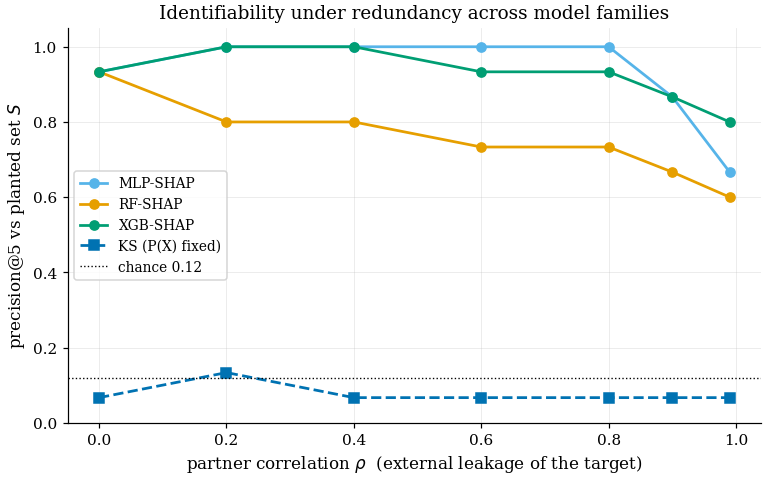

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for kind in ['mlp', 'rf', 'xgb']:
    if kind in piv.columns:
        ax.plot(piv.index, piv[kind], marker='o', color=COLOR[kind],
                label={'mlp': 'MLP-SHAP', 'rf': 'RF-SHAP', 'xgb': 'XGB-SHAP'}[kind])
if 'ks' in piv.columns:
    ax.plot(piv.index, piv['ks'], marker='s', ls='--', color=COLOR['ks'],
            label='KS (P(X) fixed)')
ax.axhline(CHANCE, ls=':', color='black', lw=0.9, label=f'chance {CHANCE:.2f}')
ax.set_xlabel(r'partner correlation $\rho$  (external leakage of the target)')
ax.set_ylabel(f'precision@{K_PRIMARY} vs planted set $S$')
ax.set_ylim(0, 1.05)
ax.set_title('Identifiability under redundancy across model families')
ax.legend(fontsize=9)
fig.tight_layout(); save_figure(fig, '12_mlp_identifiability_sweep'); plt.show()

## 8. Pre-registered verdict (D029)

In [9]:
def at(method, rho):
    return float(sweep[(sweep['method'] == method) & (sweep['rho'] == rho)]['precision'].mean())

mlp_p0 = at('mlp', 0.0); mlp_p99 = at('mlp', 0.99); mlp_drop = mlp_p0 - mlp_p99
rf_drop = at('rf', 0.0) - at('rf', 0.99)
xgb_drop = at('xgb', 0.0) - at('xgb', 0.99)
mlp_recall_min = float(sweep[sweep['method'] == 'mlp']['recall'].min())
ks_mean = float(sweep[sweep['method'] == 'ks']['precision'].mean())

recover_ok = mlp_p0 >= RHO0_MIN
drop_ok = mlp_drop >= DROP_MIN
recall_ok = mlp_recall_min >= RECALL_MIN
confirmed = recover_ok and drop_ok and recall_ok
verdict = 'NEURAL-IDENTIFIABILITY-CONFIRMED' if confirmed else 'NEURAL-IDENTIFIABILITY-NOT-CONFIRMED'

print('=' * 72)
print('CROSS-MODEL IDENTIFIABILITY SWEEP VERDICT (D029)  -- precision@%d' % K_PRIMARY)
print('=' * 72)
print(f'  rho grid {RHO_GRID} | seeds {SEEDS} | chance {CHANCE:.3f}')
print(f'  MLP:  rho=0 {mlp_p0:.3f} -> rho=0.99 {mlp_p99:.3f}  (drop {mlp_drop:+.3f})')
print(f'  RF :  drop {rf_drop:+.3f} | XGB: drop {xgb_drop:+.3f}  (tree reference)')
print(f'  MLP recall (min over rho) {mlp_recall_min:.3f} (>= {RECALL_MIN}? {recall_ok})')
print(f'  KS mean precision {ks_mean:.3f} (expect ~chance {CHANCE:.3f})')
print('-' * 72)
print(f'  gate: rho0 {mlp_p0:.3f}>={RHO0_MIN}? {recover_ok} | '
      f'drop {mlp_drop:+.3f}>={DROP_MIN}? {drop_ok} | recall ok? {recall_ok}')
print(f'--> VERDICT: {verdict}')
if confirmed:
    print('   The MLP degrades with redundancy just like the trees: the C3 structural')
    print('   identifiability limit is model-class-independent, not tree-specific. KS stays')
    print('   at chance throughout (P(X) fixed), as designed.')
else:
    print('   The MLP did not reproduce the tree degradation pattern under the gate. This is')
    print('   reportable (the failure may be partly tree-specific); inspect recall and the')
    print('   per-rho curve before drawing a conclusion.')

CROSS-MODEL IDENTIFIABILITY SWEEP VERDICT (D029)  -- precision@5
  rho grid [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99] | seeds [42, 1, 7] | chance 0.119
  MLP:  rho=0 0.933 -> rho=0.99 0.667  (drop +0.267)
  RF :  drop +0.333 | XGB: drop +0.133  (tree reference)
  MLP recall (min over rho) 0.961 (>= 0.7? True)
  KS mean precision 0.076 (expect ~chance 0.119)
------------------------------------------------------------------------
  gate: rho0 0.933>=0.8? True | drop +0.267>=0.2? True | recall ok? True
--> VERDICT: NEURAL-IDENTIFIABILITY-CONFIRMED
   The MLP degrades with redundancy just like the trees: the C3 structural
   identifiability limit is model-class-independent, not tree-specific. KS stays
   at chance throughout (P(X) fixed), as designed.


In [10]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'purpose': 'extend the identifiability sweep (C3/Fig.5) to an MLP, across model families',
    'construction': 'known-GT concept arm, P(X) fixed, planted set S, median-split labels',
    'models': MODELS, 'n_features': N_FEATURES, 'rel_size': REL_SIZE,
    'seeds': SEEDS, 'rho_grid': RHO_GRID, 'chance': CHANCE,
    'precision_vs_rho': {m: {float(r): float(piv.loc[r, m]) for r in piv.index}
                         for m in piv.columns},
    'mlp': {'rho0': mlp_p0, 'rho99': mlp_p99, 'drop': mlp_drop,
            'recall_min': mlp_recall_min},
    'tree_drops': {'rf': rf_drop, 'xgb': xgb_drop},
    'ks_mean_precision': ks_mean,
    'gate': {'rho0_min': RHO0_MIN, 'drop_min': DROP_MIN, 'recall_min': RECALL_MIN},
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F017',
    title='Identifiability under redundancy is not tree-specific: the MLP degrades like RF/XGBoost',
    context='05_phase3_generalization/12_mlp_identifiability_sweep',
    what_we_did=(
        'Extended the synthetic identifiability sweep (C3/Fig.5) from RF + XGBoost '
        'to an MLP on one shared known-GT construction (P(X) fixed, planted set S, '
        'median-split labels). Swept partner-correlation rho in '
        '{0,0.2,0.4,0.6,0.8,0.9,0.99}; recovered S by precision@K from SHAP '
        '(TreeSHAP for trees, the validated agnostic path for the MLP via '
        'shap_importance_any), with a recall gate and KS as the concept-blind '
        'baseline. D029.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. MLP-SHAP precision@%d falls from %.3f at rho=0 '
        'to %.3f at rho=0.99 (drop %+.3f), with min recall %.3f; tree reference drops '
        'RF %+.3f, XGB %+.3f; KS mean %.3f ~ chance %.3f.'
        % (K_PRIMARY, mlp_p0, mlp_p99, mlp_drop, mlp_recall_min,
           rf_drop, xgb_drop, ks_mean, CHANCE)
    ),
    why_it_matters=(
        'Answers the reviewer question on model breadth: if the MLP degrades with '
        'redundancy like the trees, the C3 identifiability limit is '
        'model-class-independent rather than an artifact of tree explainers. This is '
        'the synthetic half of the neural generalization; notebook 13 tests it on '
        'real UNSW geometry.'
    ),
)
print('F017 logged.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase3_12_mlp_identifiability.json
[FINDING LOGGED] F017: Identifiability under redundancy is not tree-specific: the MLP degrades like RF/XGBoost
F017 logged.


## 9. What this settles, and what is next

- If **CONFIRMED**: the identifiability mechanism (C3) holds for a neural model too;
  the new three-family curve replaces Fig. 5. Proceed to **notebook 13**
  (`13_mlp_unsw_benchmark.ipynb`) -- the real-geometry test (the 10b analog) that
  asks whether KS stays competitive, dual-SHAP still adds nothing, and modality
  circularity still appears, now with the MLP. That is the last planned experiment.
- If **NOT-CONFIRMED**: do not paper over it -- inspect the per-$\rho$ recall and
  curve; a genuinely different neural pattern is itself a finding and changes how
  C3 is stated.

After notebook 13: **stop adding experiments** (no CNN/LSTM/TabNet/GNN unless a
reviewer asks) and move to paper-polish mode -- figure quality, notation
consistency, trimming repetition, table polish, reproducibility package.

Record the call by hand:

In [11]:
# add_journal_entry(
#     title='Notebook 12 cross-model identifiability sweep verdict',
#     body='...the shared known-GT construction, the rho sweep for MLP/RF/XGB on the '
#          'same arms, KS flat at chance, the MLP drop vs the tree drops, the verdict, '
#          'and what it settles for C3 (model-class-independent identifiability limit).',
# )